<a href="https://colab.research.google.com/github/IlhamFaturachman/pcvk-ganjil-2025/blob/main/week6_pcvk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCVK – Modul 6: Histogram, Histogram Equalization, Dithering

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import dasar
import os, math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
print('OpenCV:', cv.__version__)

OpenCV: 4.12.0


## Utilitas I/O dan tampilan

In [3]:
def imread_color(path):
    img = cv.imread(path, cv.IMREAD_COLOR)
    if img is None:
        print(f"[PERINGATAN] Tidak menemukan {path}. Membuat contoh sintetis 256×256.")
        H, W = 256, 256
        x = np.linspace(0, 1, W)
        y = np.linspace(0, 1, H)
        X, Y = np.meshgrid(x, y)
        r = (255*X).astype(np.uint8)
        g = (255*(1-X)).astype(np.uint8)
        b = (255*Y).astype(np.uint8)
        img = cv.merge([b,g,r])
    return img

def show(title, img):
    plt.figure()
    if img.ndim==2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title); plt.axis('off'); plt.show()

def ensure_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY) if img.ndim==3 else img

## (3) Histogram citra – manual (mengikuti flowchart)

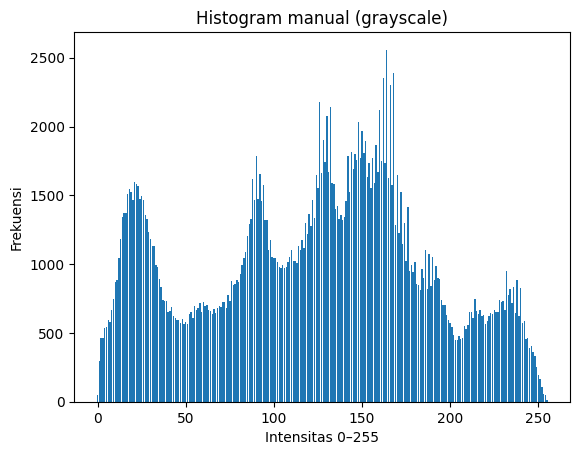

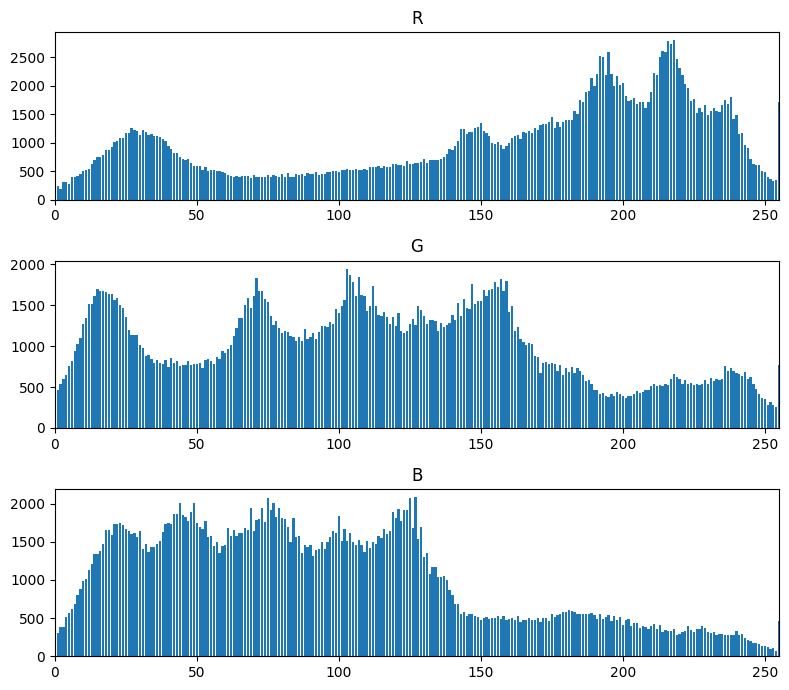

In [4]:
img_color = imread_color('/content/drive/MyDrive/PCVK/lena.jpg')
img_gray  = ensure_gray(img_color)

# Hitung histogram secara manual (grayscale)
hist_manual = np.zeros(256, dtype=np.int64)
H, W = img_gray.shape
for y in range(H):
    for x in range(W):
        hist_manual[ img_gray[y,x] ] += 1

plt.figure(); plt.bar(np.arange(256), hist_manual)
plt.title('Histogram manual (grayscale)'); plt.xlabel('Intensitas 0–255'); plt.ylabel('Frekuensi'); plt.show()

# Histogram RGB manual (opsional, memisah channel)
b,g,r = cv.split(img_color)
hist_b = np.zeros(256, dtype=np.int64)
hist_g = np.zeros(256, dtype=np.int64)
hist_r = np.zeros(256, dtype=np.int64)
for ch, hist in zip([b,g,r],[hist_b, hist_g, hist_r]):
    H, W = ch.shape
    for y in range(H):
        for x in range(W):
            hist[ch[y,x]] += 1

fig, ax = plt.subplots(3,1, figsize=(8,7))
ax[0].bar(np.arange(256), hist_r); ax[0].set_title('R');
ax[1].bar(np.arange(256), hist_g); ax[1].set_title('G');
ax[2].bar(np.arange(256), hist_b); ax[2].set_title('B');
for a in ax: a.set_xlim(0,255)
plt.tight_layout(); plt.show()

## (4) Histogram NumPy (`np.histogram`) – bandingkan hasilnya

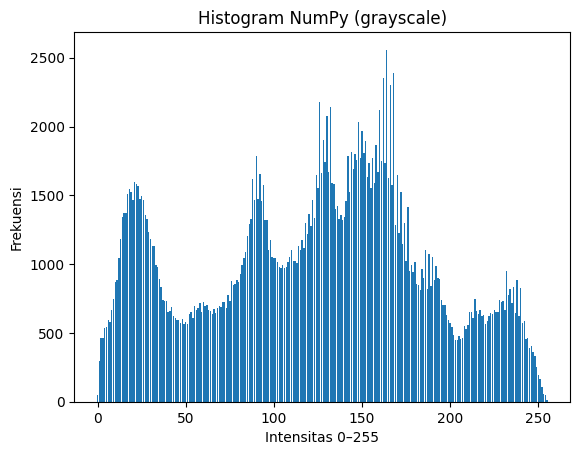

Apakah histogram manual == NumPy? -> True


In [5]:
hist_np, bins = np.histogram(img_gray, bins=256, range=(0,256))
plt.figure(); plt.bar(np.arange(256), hist_np)
plt.title('Histogram NumPy (grayscale)'); plt.xlabel('Intensitas 0–255'); plt.ylabel('Frekuensi'); plt.show()

same = np.all(hist_np == hist_manual)
print('Apakah histogram manual == NumPy? ->', bool(same))

## (5) Histogram Equalization – implementasi manual (mengikuti rumus di modul)

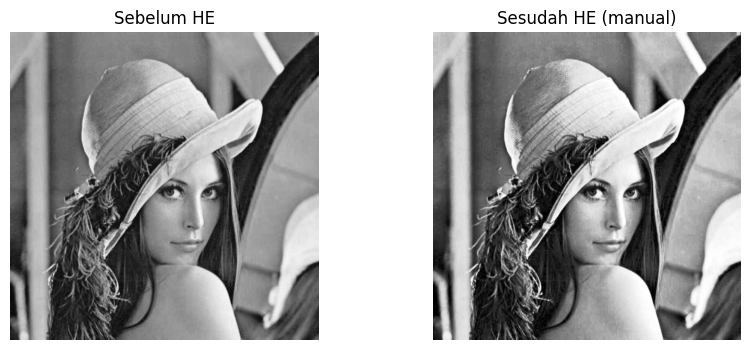

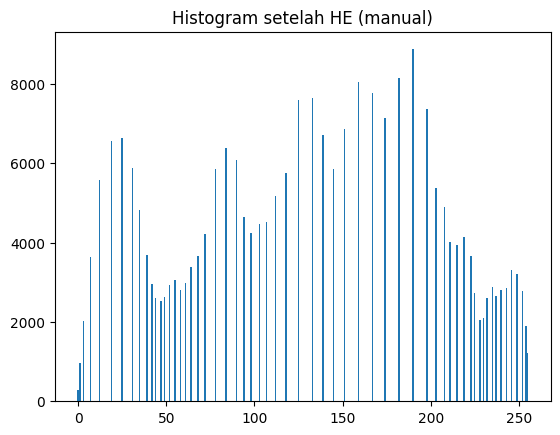

In [6]:
img_lc = imread_color('/content/drive/MyDrive/PCVK/lena_lc.jpg')
gray_lc = ensure_gray(img_lc)

# HE manual (grayscale)
hist, _ = np.histogram(gray_lc, bins=256, range=(0,256))
cdf = np.cumsum(hist).astype(np.float64)
cdf_norm = (cdf - cdf.min()) / (cdf.max() - cdf.min())
L = 256
T = np.round(cdf_norm * (L-1)).astype(np.uint8)
he_gray = T[gray_lc]

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].imshow(gray_lc, cmap='gray'); ax[0].set_title('Sebelum HE'); ax[0].axis('off')
ax[1].imshow(he_gray, cmap='gray'); ax[1].set_title('Sesudah HE (manual)'); ax[1].axis('off')
plt.show()

plt.figure(); plt.bar(np.arange(256), np.histogram(he_gray, bins=256, range=(0,256))[0])
plt.title('Histogram setelah HE (manual)'); plt.show()

## (6) Histogram Equalization – OpenCV (`cv.equalizeHist`) – bandingkan

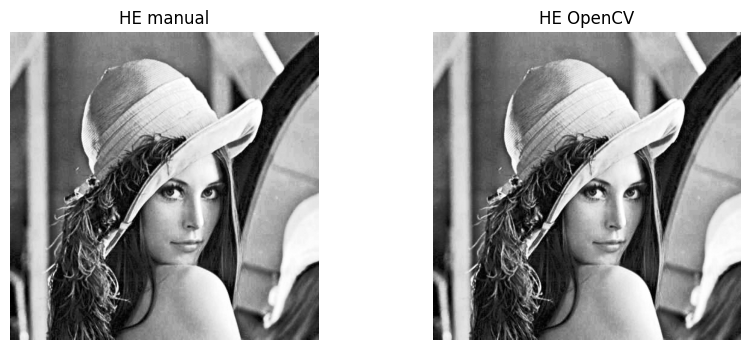

Apakah HE manual == HE OpenCV (pixel-wise)? -> True


In [7]:
he_cv = cv.equalizeHist(gray_lc)
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].imshow(he_gray, cmap='gray'); ax[0].set_title('HE manual') ; ax[0].axis('off')
ax[1].imshow(he_cv,  cmap='gray'); ax[1].set_title('HE OpenCV'); ax[1].axis('off')
plt.show()
identik = np.array_equal(he_gray, he_cv)
print('Apakah HE manual == HE OpenCV (pixel-wise)? ->', bool(identik))

## (7) Pemetaan 16 juta warna (RGB) → 8 warna (black, red, green, blue, yellow, magenta, cyan, white)

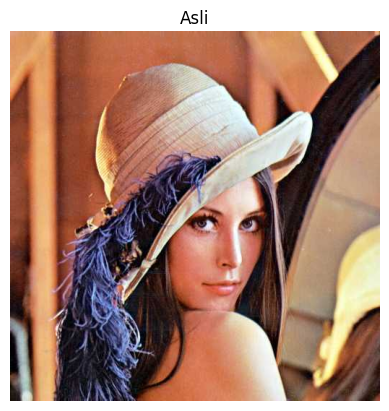

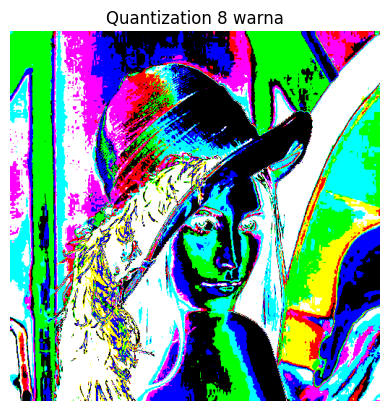

In [8]:
img = imread_color('/content/drive/MyDrive/PCVK/lena.jpg')

# Definisikan palet 8-warna (BGR karena OpenCV)
palette_bgr = np.array([
    [0,0,0],       # black
    [0,0,255],     # red
    [0,255,0],     # green
    [255,0,0],     # blue
    [0,255,255],   # yellow (BGR order is blue,green,red)
    [255,0,255],   # magenta
    [255,255,0],   # cyan
    [255,255,255], # white
], dtype=np.uint8)

H, W = img.shape[:2]
flat = img.reshape(-1,3).astype(np.int16)
dists = np.sum((flat[:,None,:] - palette_bgr[None,:,:])**2, axis=2)
idx = np.argmin(dists, axis=1)
quant = palette_bgr[idx].reshape(H,W,3)

show('Asli', img)
show('Quantization 8 warna', quant)

## (8) Dithering Floyd–Steinberg (warna & grayscale)

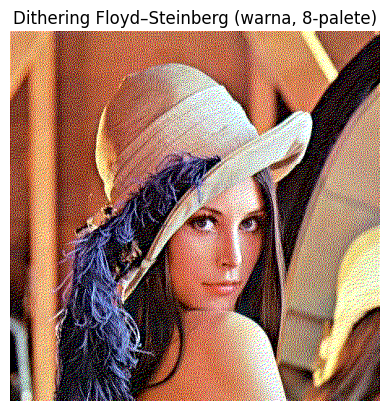

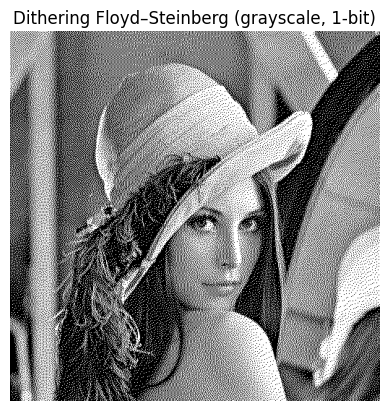

In [9]:
def floyd_steinberg_gray(gray):
    gray = gray.astype(np.float64).copy()
    H, W = gray.shape
    out = np.zeros_like(gray, dtype=np.uint8)
    for y in range(H):
        for x in range(W):
            old = gray[y,x]
            new = 0 if old < 128 else 255
            out[y,x] = new
            err = old - new
            if x+1 < W: gray[y,  x+1] += err * 7/16
            if y+1 < H and x-1 >= 0: gray[y+1,x-1] += err * 3/16
            if y+1 < H: gray[y+1,x  ] += err * 5/16
            if y+1 < H and x+1 < W: gray[y+1,x+1] += err * 1/16
    return np.clip(out,0,255).astype(np.uint8)

def floyd_steinberg_color(bgr, palette_bgr):
    H,W,_ = bgr.shape
    work = bgr.astype(np.float64).copy()
    out = np.zeros_like(bgr, dtype=np.uint8)
    for y in range(H):
        for x in range(W):
            old = work[y,x]
            diffs = palette_bgr.astype(np.float64) - old
            idx = np.argmin(np.sum(diffs*diffs, axis=1))
            new = palette_bgr[idx]
            out[y,x] = new
            err = (old - new).astype(np.float64)
            if x+1 < W: work[y,  x+1] += err * 7/16
            if y+1 < H and x-1 >= 0: work[y+1,x-1] += err * 3/16
            if y+1 < H: work[y+1,x  ] += err * 5/16
            if y+1 < H and x+1 < W: work[y+1,x+1] += err * 1/16
    return np.clip(out,0,255).astype(np.uint8)

img_color = imread_color('/content/drive/MyDrive/PCVK/lena.jpg')
img8 = floyd_steinberg_color(img_color, palette_bgr)
show('Dithering Floyd–Steinberg (warna, 8-palete)', img8)

gray = ensure_gray(img_color)
dither_gray = floyd_steinberg_gray(gray)
show('Dithering Floyd–Steinberg (grayscale, 1-bit)', dither_gray)

## (9) Lena LC → grayscale → HE → Dithering Floyd–Steinberg

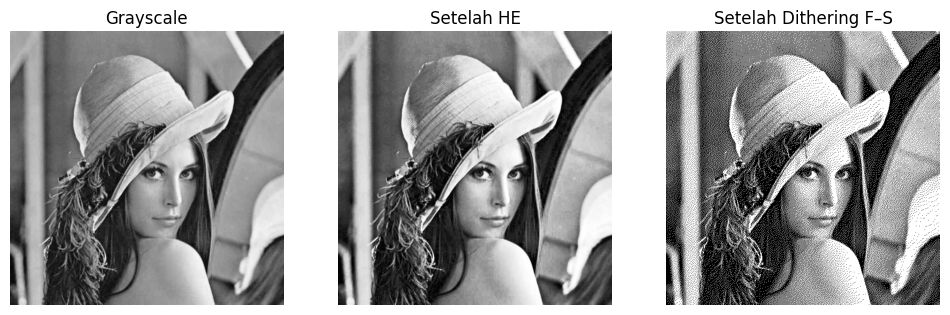

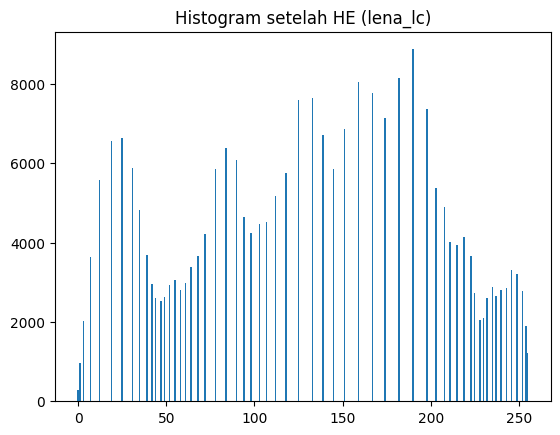

In [10]:
lc = imread_color('/content/drive/MyDrive/PCVK/lena_lc.jpg')
lc_gray = ensure_gray(lc)
lc_he = cv.equalizeHist(lc_gray)
lc_dither = floyd_steinberg_gray(lc_he)

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(lc_gray, cmap='gray'); ax[0].set_title('Grayscale'); ax[0].axis('off')
ax[1].imshow(lc_he,   cmap='gray'); ax[1].set_title('Setelah HE'); ax[1].axis('off')
ax[2].imshow(lc_dither, cmap='gray'); ax[2].set_title('Setelah Dithering F–S'); ax[2].axis('off')
plt.show()

plt.figure(); plt.bar(np.arange(256), np.histogram(lc_he, bins=256, range=(0,256))[0])
plt.title('Histogram setelah HE (lena_lc)'); plt.show()

**Catatan implementasi**:
- Histogram manual mengikuti *flowchart* (p.10), HE manual mengikuti rumus CDF→transform (p.4–5), dan Floyd–Steinberg memakai kernel 7/16, 3/16, 5/16, 1/16 sesuai penjelasan & flowchart (p.6–7 & p.15) pada modul.